In [ ]:
!pip uninstall torch torchvision torchaudio -y
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128 --force-reinstall
!pip install pandas matplotlib
!pip install ultralytics

In [7]:
import torch
print(torch.__version__)
print(torch.__file__)  # shows exactly which installation is being used

2.11.0+cu128
c:\Users\mrgum\miniconda3\envs\yolo_model_test\Lib\site-packages\torch\__init__.py


In [ ]:
import ultralytics
from ultralytics import YOLO

model = YOLO('yolov8n.pt') 

In [3]:
import json, os

COCO_JSON_PATH  = r'C:\Users\mrgum\Desktop\Yolo_model_test\yolo\test_for_tracking\_annotations.coco.json'
IMAGES_DIR      = r'C:\Users\mrgum\Desktop\Yolo_model_test\yolo\test_for_tracking\images'
OUTPUT_LABELS   = r'C:\Users\mrgum\Desktop\Yolo_model_test\yolo\test_for_tracking\labels'

with open(COCO_JSON_PATH) as f:
    data = json.load(f)

cat_id_to_idx = {cat["id"]: i for i, cat in enumerate(data["categories"])}
ann_by_image  = {}
for ann in data["annotations"]:
    ann_by_image.setdefault(ann["image_id"], []).append(ann)

os.makedirs(OUTPUT_LABELS, exist_ok=True)
converted, skipped = 0, 0

for img in data["images"]:
    img_path = os.path.join(IMAGES_DIR, img["file_name"])
    if not os.path.exists(img_path):
        skipped += 1
        continue

    label_name = os.path.splitext(img["file_name"])[0] + ".txt"
    with open(os.path.join(OUTPUT_LABELS, label_name), "w") as lf:
        for ann in ann_by_image.get(img["id"], []):
            x, y, w, h = ann["bbox"]
            xc = (x + w/2) / img["width"]
            yc = (y + h/2) / img["height"]
            nw = w / img["width"]
            nh = h / img["height"]
            lf.write(f"{cat_id_to_idx[ann['category_id']]} {xc:.6f} {yc:.6f} {nw:.6f} {nh:.6f}\n")
    converted += 1

print(f"Done! Converted: {converted} | Skipped (missing images): {skipped}")
print(f"Labels saved to: {OUTPUT_LABELS}")

Done! Converted: 300 | Skipped (missing images): 703
Labels saved to: C:\Users\mrgum\Desktop\Yolo_model_test\yolo\test_for_tracking\labels


In [14]:
results = model.train(
    data=r'C:\Users\mrgum\Desktop\Yolo_model_test\yolo\yolo_annotations\dataset.yaml',
    epochs=50,
    imgsz=640,
    batch=8,          # safe for 6GB VRAM, increase to 16 if no memory errors
    device=0,         # 0 = use your GPU
    project='yolo_pedestrian',
    name='run1',
    patience=10       # stops early if no improvement after 10 epochs
)

Ultralytics 8.4.57  Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\mrgum\Desktop\Yolo_model_test\yolo\yolo_annotations\dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=run1-3, nbs=64, nms=False, opset=None,

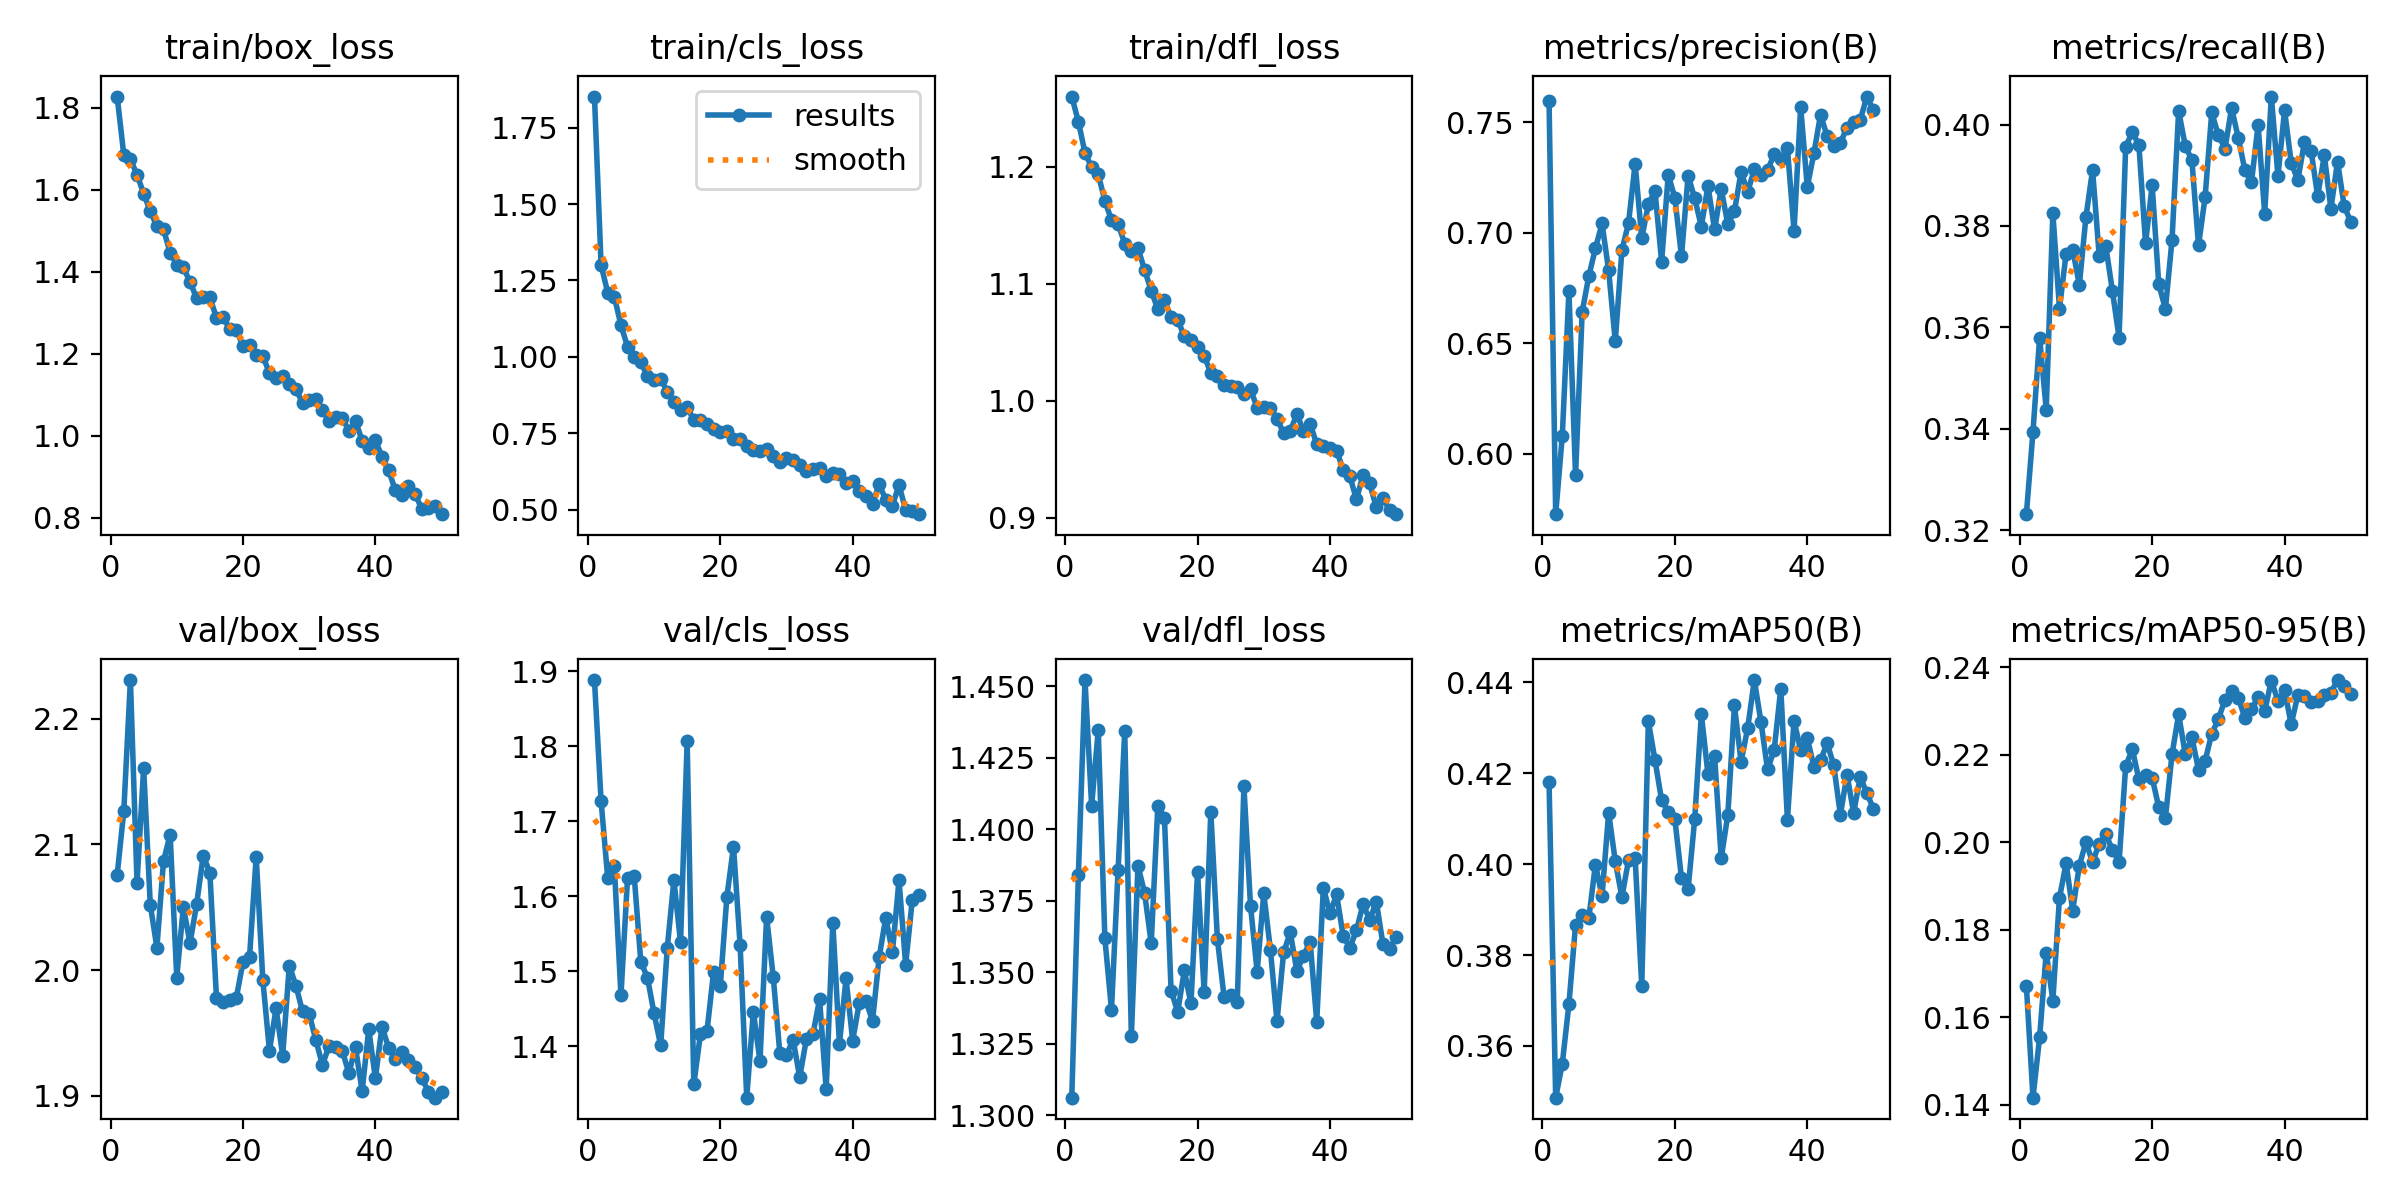

In [20]:
from IPython.display import Image, display

display(Image(filename=r'C:\Users\mrgum\Desktop\Yolo_model_test\runs\detect\yolo_pedestrian\run1-3\results.png'))

In [18]:
import os

# find where the run was saved
base = r'C:\Users\mrgum\Desktop\Yolo_model_test'
for root, dirs, files in os.walk(base):
    for f in files:
        if 'results' in f.lower():
            print(os.path.join(root, f))

C:\Users\mrgum\Desktop\Yolo_model_test\runs\detect\train-6\results.csv
C:\Users\mrgum\Desktop\Yolo_model_test\runs\detect\train-7\results.csv
C:\Users\mrgum\Desktop\Yolo_model_test\runs\detect\train-7\results.png
C:\Users\mrgum\Desktop\Yolo_model_test\runs\detect\yolo_pedestrian\run1\results.csv
C:\Users\mrgum\Desktop\Yolo_model_test\runs\detect\yolo_pedestrian\run1-2\results.csv
C:\Users\mrgum\Desktop\Yolo_model_test\runs\detect\yolo_pedestrian\run1-2\results.png
C:\Users\mrgum\Desktop\Yolo_model_test\runs\detect\yolo_pedestrian\run1-3\results.csv
C:\Users\mrgum\Desktop\Yolo_model_test\runs\detect\yolo_pedestrian\run1-3\results.png


In [21]:
from ultralytics import YOLO

model = YOLO(r'C:\Users\mrgum\Desktop\Yolo_model_test\runs\detect\yolo_pedestrian\run1-3\weights\best.pt')

metrics = model.val()
print(f"mAP50:     {metrics.box.map50:.3f}")
print(f"mAP50-95:  {metrics.box.map:.3f}")
print(f"Precision: {metrics.box.mp:.3f}")
print(f"Recall:    {metrics.box.mr:.3f}")

Ultralytics 8.4.57  Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 471.3386.7 MB/s, size: 225.3 KB)
val: Scanning C:\Users\mrgum\Desktop\Yolo_model_test\yolo\test_for_tracking\labels.cache... 300 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 300/300  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 2.8it/s 6.7s0.1s
                   all        300       7319       0.75      0.393       0.42      0.238
Speed: 4.2ms preprocess, 3.5ms inference, 0.0ms loss, 7.3ms postprocess per image
Results saved to C:\Users\mrgum\Desktop\Yolo_model_test\runs\detect\val
mAP50:     0.420
mAP50-95:  0.238
Precision: 0.750
Recall:    0.393



image 1/1 C:\Users\mrgum\Desktop\Yolo_model_test\yolo\good_people_walking\images\000001_jpg.rf.504d0a1800636a03a4e92591fc11aad1.jpg: 384x640 56 Pedestrians, 47.8ms
Speed: 3.1ms preprocess, 47.8ms inference, 3.5ms postprocess per image at shape (1, 3, 384, 640)
Results saved to C:\Users\mrgum\Desktop\Yolo_model_test\runs\detect\yolo_pedestrian\predict1


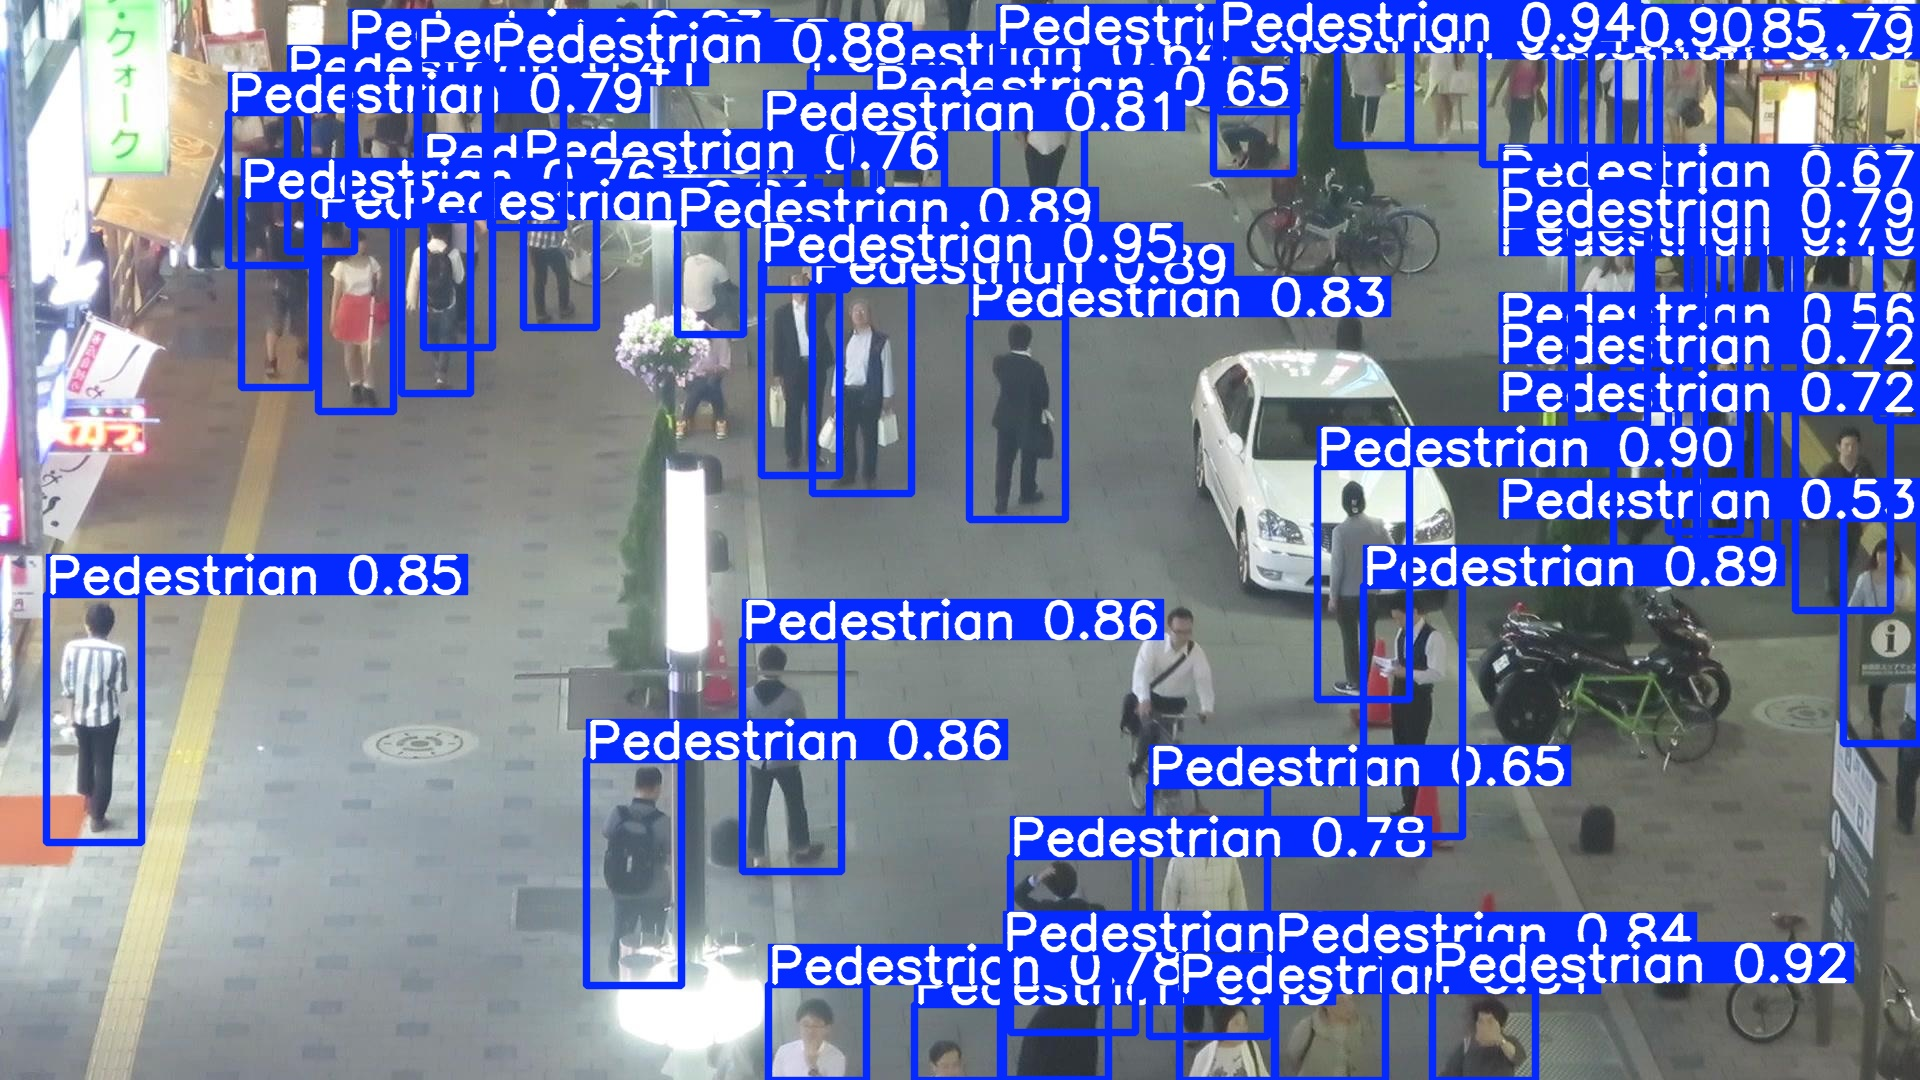

In [23]:
results = model.predict(
    source=r'C:\Users\mrgum\Desktop\Yolo_model_test\yolo\good_people_walking\images\000001_jpg.rf.504d0a1800636a03a4e92591fc11aad1.jpg',
    conf=0.25,
    save=True,
    project='yolo_pedestrian',
    name='predict1'
)

display(Image(filename=r'C:\Users\mrgum\Desktop\Yolo_model_test\runs\detect\yolo_pedestrian\predict1\000001_jpg.rf.504d0a1800636a03a4e92591fc11aad1.jpg'))

In [ ]:
from ultralytics import YOLO

model = YOLO(r'C:\Users\mrgum\Desktop\Yolo_model_test\runs\detect\yolo_pedestrian\run1-3\weights\best.pt')

results = model.predict(
    source=r'C:\Users\mrgum\Desktop\Yolo_model_test\Multi-Family Arrest of the Month_ Mailroom Intruder Arrested at Denver Apartment Community.mp4',
    conf=0.50,        
    iou=0.45,
    save=True,
    project=r'C:\Users\mrgum\Desktop\Yolo_model_test\runs\detect\yolo_pedestrian',
    name='video_predict2'
)


WARNING 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/1738) C:\Users\mrgum\Desktop\Yolo_model_test\Multi-Family Arrest of the Month_ Mailroom Intruder Arrested at Denver Apartment Community.mp4: 384x640 (no detections), 5.5ms
video 1/1 (frame 2/1738) C:\Users\mrgum\Desktop\Yolo_model_test\Multi-Family Arrest of the Month_ Mailroom Intruder Arrested at Denver Apartment Community.mp4: 384x640 (no detections), 4.7ms
video 1/1 (frame 3/1738) C:\Users\mrgum\Desktop\Yolo_model_test\Multi-Family Ar